In [12]:
import pandas as pd
import numpy as np
import hnswlib
from time import time
import matplotlib.pyplot as plt

In [ ]:
# e5-small-v2
df = pd.read_json("hf://datasets/mteb/index-NFCorpus-test-intfloat_e5-small-v2/embedding.jsonl", lines=True)

# multilingual-e5-large
# df = pd.read_json("hf://datasets/mteb/index-MIRACLRetrieval-th-intfloat_multilingual-e5-large/embedding.jsonl", lines=True)

d:\Dokumentumok\MSc\F3_TudLab\EX9BLV_HNSW_Preordering\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Alap adathalmaz statisztikák
print(f"Count: {len(df)}")
print(df.keys())
print(f"Dim: {len(df.vector[0])}")
print(f"{df.vector[0][0]} - {type(df.vector[0][0])}")

Count: 3633
Index(['id', 'vector', 'text'], dtype='str')
Dim: 384
-0.089692406356334 - <class 'float'>


In [79]:
class KNN:
    def __init__(self, data):
        self._data = data

    def euclidian_distance(x, y):
        if len(x) != len(y):
            raise ValueError("Dimensions not matching!")
        
        sum = 0
        for i in range(0, len(x)):
            sum += (y[i] - x[i]) ** 2
        return np.sqrt(sum)

    def get_KNN(self, q, k, distance = euclidian_distance):
        distances = [distance(q, v) for v in self._data]
        knn_index = np.argsort(distances) # rendezés index szerint
        knn_index = knn_index[np.asarray(distances)[knn_index] > 0] # 0 távolságú indexek eldobása
        knn_index = knn_index[:k] # első k elem
        return np.array(knn_index)

In [137]:
class HNSW_benchmark:
    def __init__(self, data, M = 16, ef_construction = 128):
        if len(data) == 0 or len(data[0]) == 0:
            raise ValueError("Bad dataset given. Count or dimension = 0")
        
        # alap adatok
        self._data = [np.array(v) for v in data]
        self._M = M
        self._ef_construction = ef_construction
        # KNN init
        self._knn = KNN(data)
        # HNSW init
        self._hnsw = hnswlib.Index(space        = 'l2',
                                   dim          = len(self._data[0]))
        self._hnsw.init_index(max_elements      = len(self._data),
                              M                 = self._M,
                              ef_construction   = self._ef_construction)
        self._hnsw.add_items(data               = self._data)

    def reconstruct_HNSW(self):
        self._hnsw.init_index(max_elements      = len(self._data),
                              M                 = self._M,
                              ef_construction   = self._ef_construction)
        self._hnsw.add_items(data               = self._data)

    def run(self, q, n_tries = 1, k = 10, ef_search = 40):
        # Várt eredmény (recall = 1) kiszámítása
        R_E = self._knn.get_KNN(q, k)
        R_E = set(R_E)

        # HNSW keresési beállítások
        self._hnsw.set_ef(ef_search)

        # HNSW futtatása n_tries-szor, és recall számítása
        sum_recall = 0
        for i in range(0, n_tries):
            R_A = self._hnsw.knn_query([q], k, filter=(lambda x: KNN.euclidian_distance(self._data[x], q) > 0))
            sum_recall += len(R_E & set(R_A[0][0])) / k # R_E union R_A / ||R_E||

        return sum_recall / n_tries

    def run_multiple(self, qs, n_tries = 1, k = 10, ef_search = 40, stats = False):
        if stats:
            start = time()
        recalls = [self.run(q, n_tries, k, ef_search) for q in qs]
        if stats:
            elapsed = time() - start
            start = time()
            print(f"Minimum recall: {np.min(recalls_normal):.4f}")
            print(f"Average recall: {np.mean(recalls_normal):.4f}")
            print(f"Maximum recall: {np.max(recalls_normal):.4f}")
            print(f"Total time: {elapsed:.3f} seconds")
            print(f"Average time per query: {elapsed / len(qs) * 1000:.3f} ms")
        return recalls

    

In [135]:
# LID@k értékek meghatározása az adathalmazban minden pontra
def calculate_lid(data, k=100):
    vectors = np.asarray(list(data), dtype=np.float32)
    n = len(vectors)

    if n <= k:
        raise ValueError(f"Dataset must contain more than k={k} vectors.")

    knn = KNN(vectors)
    lid_values = np.full(n, np.nan, dtype=np.float64)

    # LID számítása egyes vektorokra
    for i, vector in enumerate(vectors):
        # KNN számítás
        neighbor_indices = knn.get_KNN(vector, k)
        #Távolságok számítása
        distances = np.array([KNN.euclidian_distance(vector, vectors[j]) for j in neighbor_indices])

        distances = distances[distances > 0]

        if len(distances) < k:
            print(f"Point: {i}")
            print(neighbor_indices[:10])
            raise ValueError(f"Some elements deleted.")

        r_k = distances[-1]
        sum_log = np.sum(np.log2(distances / r_k)) # ln lenne helyes, de mindegy a rangsorolás szempontjából, mivel mindegyik log fv. szig. mon. növ.
        lid_values[i] = -((sum_log / k) ** -1)

    return lid_values

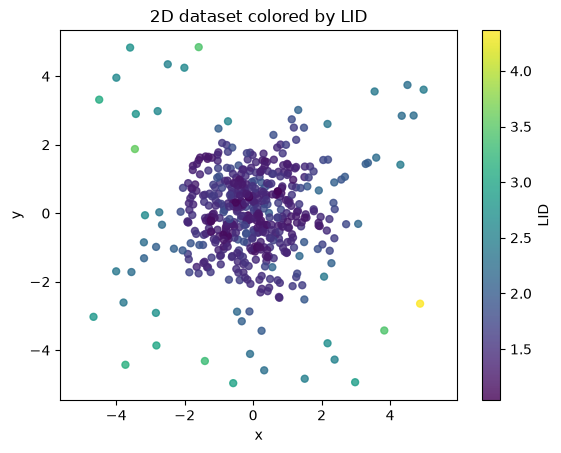

In [ ]:
# calculate_lid tesztelése 2D-s adathalmazra
rng_2d = np.random.default_rng(200)

clustered = rng_2d.normal(loc=0, scale=1, size=(450, 2))
scattered = rng_2d.uniform(low=-5, high=5, size=(50, 2))

points_2d = np.vstack([clustered, scattered])
rng_2d.shuffle(points_2d)

lid_values_2d = calculate_lid(points_2d, k=50)

plt.scatter(
    points_2d[:, 0],
    points_2d[:, 1],
    c=lid_values_2d,
    cmap="viridis",
    s=25,
    alpha=0.8,
)
plt.colorbar(label="LID")
plt.title("2D dataset colored by LID")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [99]:
# LID számolás df.vector-ra
df_lid = calculate_lid(df.vector, k=100)

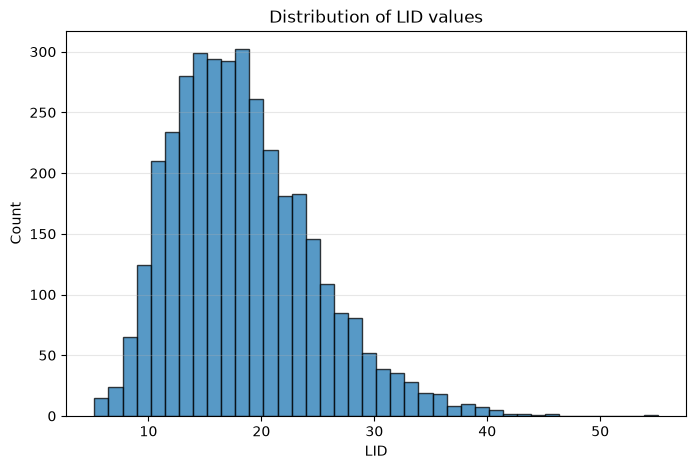

In [104]:
plt.figure(figsize=(8, 5))
plt.hist(df_lid, bins=40, edgecolor="black", alpha=0.75)
plt.title("Distribution of LID values")
plt.xlabel("LID")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [138]:
# Tesztelési alapadatok
query_pool = 1000
k = 10
ef_search = 40

# Teszt halmaz létrehozása
rng = np.random
indices = rng.choice(len(df), size=query_pool, replace=False)
queries = [df.vector.iloc[i] for i in indices]


# HNSW_benchmark teszt futás - Random beszúrással
bm_normal = HNSW_benchmark(data=df.vector)

print("-------------------------------------------")
print("HNSW benchmark - Random order")
recalls_normal = bm_normal.run_multiple(queries, k=k, ef_search=ef_search, stats=True)


# HNSW_benchmark teszt futás - LID szerint csökkenő sorrendben való beszúrással
df_lid_desc_index = np.argsort(df_lid, descending=True)
df_lid_desc = [df.vector[i] for i in df_lid_desc_index]
bm_lid_desc = HNSW_benchmark(data=df_lid_desc)

print("-------------------------------------------")
print("HNSW benchmark - LID descending order")
recalls_lid_desc = bm_lid_desc.run_multiple(queries, k=k, ef_search=ef_search, stats=True)


# HNSW_benchmark teszt futás - LID szerint növekvő sorrendben való beszúrással
df_lid_asc_index = np.argsort(df_lid, descending=False)
df_lid_asc = [df.vector[i] for i in df_lid_asc_index]
bm_lid_asc = HNSW_benchmark(data=df_lid_asc)

print("-------------------------------------------")
print("HNSW benchmark - LID ascending order")
recalls_lid_asc = bm_lid_asc.run_multiple(queries, k=k, ef_search=ef_search, stats=True)

-------------------------------------------
HNSW benchmark - Random order
Minimum recall: 0.7000
Average recall: 0.9904
Maximum recall: 1.0000
Total time: 263.803 seconds
Average time per query: 263.803 ms
-------------------------------------------
HNSW benchmark - LID descending order
Minimum recall: 0.6000
Average recall: 0.9877
Maximum recall: 1.0000
Total time: 263.056 seconds
Average time per query: 263.056 ms
-------------------------------------------
HNSW benchmark - LID ascending order
Minimum recall: 0.6000
Average recall: 0.9877
Maximum recall: 1.0000
Total time: 261.669 seconds
Average time per query: 261.669 ms
